**Exploratory Data Analysis (EDA)**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
# ------------------------------------------
# 1. Dataset Loading & Inspection
# ------------------------------------------
df = pd.read_csv('../data/digital_marketing_campaign_dataset.csv')

print("--- Dataset Overview ---")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types & Missing Values:")
print(df.info())

--- Dataset Overview ---
Total Records: 8000
Total Features: 20

First 5 Rows:


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1



Data Types & Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   str    
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   str    
 5   CampaignType         8000 non-null   str    
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases  


--- Target Distribution (Conversion) ---
Non-Converted (0): 988 (12.35%)
Converted (1): 7012 (87.65%)


C:\Users\compu zone\AppData\Local\Temp\ipykernel_10984\498557569.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette=['#e74c3c', '#2ecc71'])


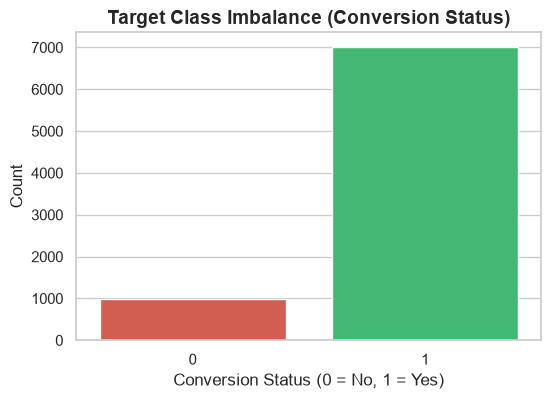

In [7]:
# ------------------------------------------
# 2. Target Class Imbalance Analysis
# ------------------------------------------
target_col = 'Conversion'

conversion_counts = df[target_col].value_counts()
conversion_pct = df[target_col].value_counts(normalize=True) * 100

print(f"\n--- Target Distribution ({target_col}) ---")
print(f"Non-Converted (0): {conversion_counts[0]} ({conversion_pct[0]:.2f}%)")
print(f"Converted (1): {conversion_counts[1]} ({conversion_pct[1]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette=['#e74c3c', '#2ecc71'])
plt.title('Target Class Imbalance (Conversion Status)', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Insight: Significant target class imbalance detected (~87.6% vs ~12.4%).
# Action: Model evaluation must prioritize Precision, Recall, and ROC-AUC over Accuracy.


--- Numerical Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
CustomerID,8000.0,11999.500000,2309.545410,8000.000000,9999.750000,11999.500000,13999.250000,15999.000000
Age,8000.0,43.625500,14.902785,18.000000,31.000000,43.000000,56.000000,69.000000
Income,8000.0,84664.196750,37580.387945,20014.000000,51744.500000,84926.500000,116815.750000,149986.000000
AdSpend,8000.0,5000.944830,2838.038153,100.054813,2523.221165,5013.440044,7407.989369,9997.914781
ClickThroughRate,8000.0,0.154829,0.084007,0.010005,0.082635,0.154505,0.228207,0.299968
ConversionRate,8000.0,0.104389,0.054878,0.010018,0.056410,0.104046,0.152077,0.199995
WebsiteVisits,8000.0,24.751625,14.312269,0.000000,13.000000,25.000000,37.000000,49.000000
PagesPerVisit,8000.0,5.549299,2.607358,1.000428,3.302479,5.534257,7.835756,9.999055
TimeOnSite,8000.0,7.727718,4.228218,0.501669,4.068340,7.682956,11.481468,14.995311
SocialShares,8000.0,49.799750,28.901165,0.000000,25.000000,50.000000,75.000000,99.000000


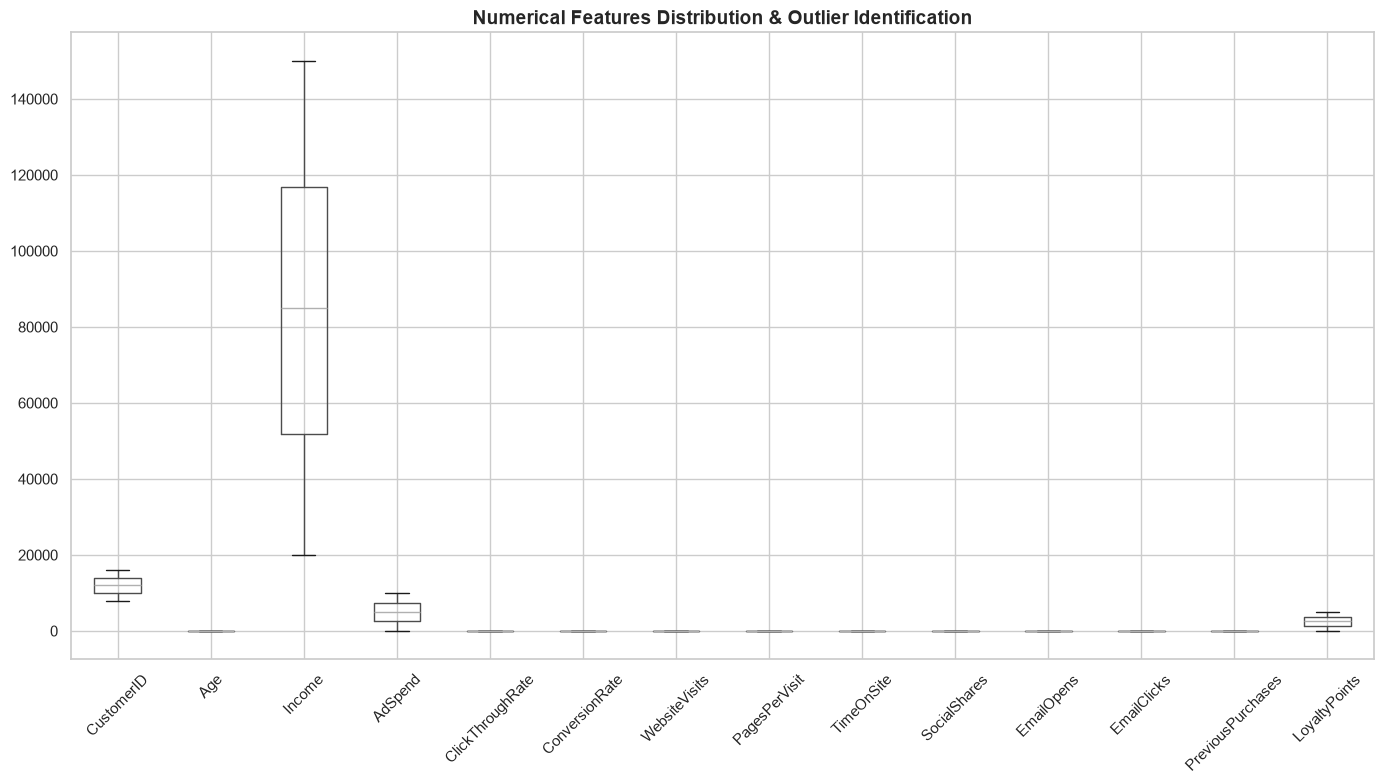

In [8]:
# ------------------------------------------
# 3. Numerical Feature Distributions & Outliers (IQR)
# ------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore')

print("\n--- Numerical Summary Statistics ---")
display(df[num_cols].describe().T)

# Outlier Detection Plot
plt.figure(figsize=(14, 8))
df[num_cols].boxplot(rot=45)
plt.title('Numerical Features Distribution & Outlier Identification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\compu zone\AppData\Local\Temp\ipykernel_10984\3065091575.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='TimeOnSite', ax=axes[0], palette='Set2')
C:\Users\compu zone\AppData\Local\Temp\ipykernel_10984\3065091575.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='PagesPerVisit', ax=axes[1], palette='Set2')
C:\Users\compu zone\AppData\Local\Temp\ipykernel_10984\3065091575.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='ClickThroughRate', ax=axes[2]

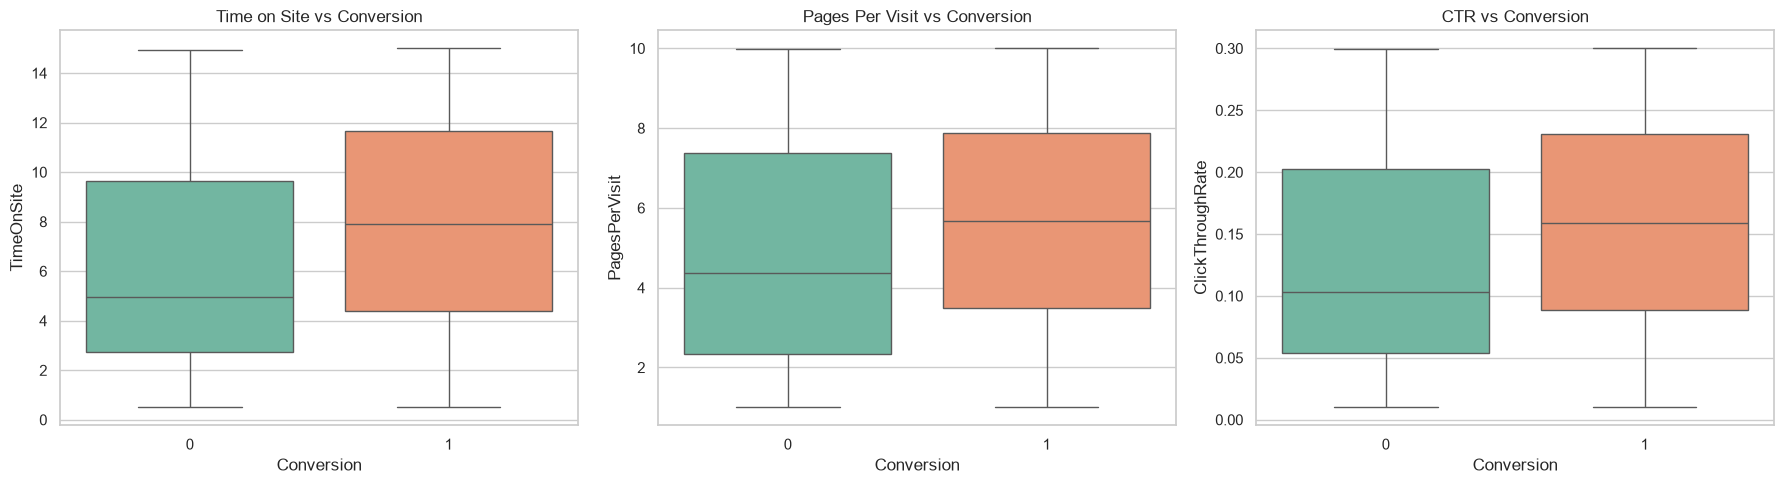

In [9]:
# ------------------------------------------
# 4. Behavioral Features vs. Conversion Rate
# ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x=target_col, y='TimeOnSite', ax=axes[0], palette='Set2')
axes[0].set_title('Time on Site vs Conversion')

sns.boxplot(data=df, x=target_col, y='PagesPerVisit', ax=axes[1], palette='Set2')
axes[1].set_title('Pages Per Visit vs Conversion')

sns.boxplot(data=df, x=target_col, y='ClickThroughRate', ax=axes[2], palette='Set2')
axes[2].set_title('CTR vs Conversion')

plt.tight_layout()
plt.show()

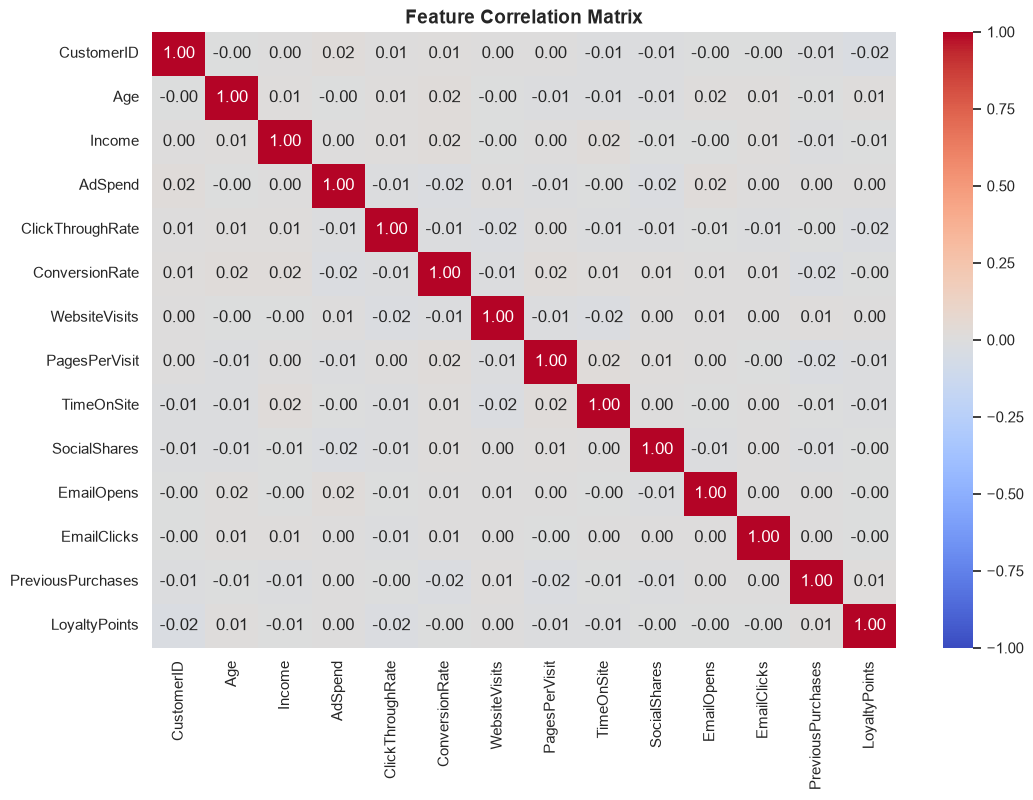

In [10]:
# ------------------------------------------
# 5. Correlation Heatmap
# ------------------------------------------
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()